<a href="https://colab.research.google.com/github/MageroOduor/Ngao-Lab-Cohort-2/blob/master/6_Urban_Air_Pollution_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#6.Urban Air Pollution Prediction Challenge
**Authors**:

- Gloria Melody
- Magero Oduor

Project Repository: GitHub: https://github.com/MageroOduor/Ngao-Lab-Cohort-2

NB: Ensure all dataset files are stored in a data folder in unzipped format. This prevents file path errors and ensures smooth, consistent data loading during analysis.

Date: 22 March 2026





# EDA

EDA was conducted to understand the structure, quality, and statistical properties of the dataset before modeling. Initial inspection involved viewing the first rows of the training data and examining dataset information to verify variable types and identify potential inconsistencies. The dimensions of the training and test datasets were also compared to ensure that both contained the same set of features, except for the target variable. Any additional variables found in the training data but not present in the test set were investigated and identified as potential target leakages, which were removed to maintain consistency between the datasets.

The analysis further examined missing values across the dataset. Columns with a high proportion of missing values were identified and removed during preprocessing, while those with smaller amounts of missing data were retained for imputation. To understand the distributions of variables requiring imputation, histograms were plotted for numerical columns containing missing values. However, due to the large number of variables, descriptive statistics were also computed to provide a clearer summary of each feature’s characteristics.

A custom descriptive statistics function was used to generate key metrics such as count, missing values, percentage of missing data, mean, median, standard deviation, minimum, quartiles, maximum, and skewness for all numerical variables. This allowed a more comprehensive understanding of feature distributions and helped guide decisions regarding imputation and transformation. Finally, histograms were produced for all numerical variables to visualize their distributions, identify skewness, and detect potential outliers. These insights informed subsequent preprocessing and modeling steps by highlighting patterns, irregularities, and statistical properties within the dataset.

The satellite viewing and solar geometry variables exhibited very high correlations across gases (many above 0.9), indicating strong multicollinearity. Since these variables represent the same measurement geometry repeated for different gas products, only one representative set (NO2 angles) was retained while the others were removed to reduce redundancy and improve model stability.


In [ ]:
###EDA
# Import required libraries for plotting and numerical operations
import matplotlib.pyplot as plt # Used for creating static, interactive, and animated visualizations in Python
import seaborn as sns # Used for making statistical graphics in Python, built on matplotlib
import numpy as np # Ensure numpy is imported for np.number, used for numerical operations
import pandas as pd # Ensure pandas is imported for pd.DataFrame, etc., used for data manipulation and analysis
from sklearn.preprocessing import StandardScaler # For data scaling section, used to standardize features by removing the mean and scaling to unit variance

# TEMPORARY FIX: Redefine wrangle function here to resolve TypeError: 'module' object is not callable
def wrangle(path):
    # load data
    df=pd.read_csv(path)

    # convert date cols to date type
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

    # drop leakages
    df=df.drop(columns=['target_min','target_max','target_variance','target_count'],errors='ignore')

    # drop cols with high null count
    mask_na=df.isna().mean()>0.5
    df.drop(columns=df.columns[mask_na],inplace=True)

    ## imputation
    # select cols with low null count for imputation
    num_cols_na = df.columns[df.isna().sum() > 0]

    # compute skewness-helps decided cols to be imputed with mean or medain
    skew = df[num_cols_na].skew()

    # separate cols : those to be imputed with mean from those imputed with median
    mean_cols = skew[skew.abs() < 0.5].index
    median_cols = skew[skew.abs() >= 0.5].index
    # compute stats from df
    mean_values = df[mean_cols].mean()
    median_values = df[median_cols].median()
    # imputation with respective stats
    df[mean_cols] = df[mean_cols].fillna(mean_values)
    df[median_cols] = df[median_cols].fillna(median_values)
    ## dealing with multicollinearity
    #multicollinearity on geometry cols (angle columns)
    sat_cols=df.filter(regex='(O3|CO|HCHO|SO2|CLOUD|AER_AI)_(sensor|solar)_(azimuth|zenith)_angle').columns
    df=df.drop(columns=df[sat_cols])

    # remove outliers only if 'target' exists
    if 'target' in df.columns:
        df = df[df['target'] < 500]

    return df

# Load and wrangle train and test data to ensure consistent state
train = wrangle('train.csv') # Load and wrangle the training dataset
test = wrangle('test.csv')   # Load and wrangle the test dataset

# checks top 5 rows of wrangled data
print("Train head:")
display(train.head()) # Display the first 5 rows of the training DataFrame
print("\nTrain info:")
train.info() # Print a concise summary of the training DataFrame, including data types and non-null values
print("\nTest info:")
test.info() # Print a concise summary of the test DataFrame

# check dim - ensures that test and train have appropriate dimensions
print("\nTrain shape:", train.shape) # Print the shape (number of rows and columns) of the training DataFrame
print("Test shape:", test.shape) # Print the shape of the test DataFrame

print('\nChecking for columns in train that are not in test (excluding "target")\n')
# check for cols in train and not in test, excluding 'target'
train_cols_no_target = set(train.columns) - {'target'} # Create a set of training column names, excluding 'target'
diff_cols = train_cols_no_target - set(test.columns) # Find columns present in train but not in test
if diff_cols: # If there are any differing columns
    print(f"Columns in train but not in test (excluding 'target'): {diff_cols}") # Print the names of these columns
    print("\nThese columns are expected differences, likely due to the target variable in the training set.\n") # Explain the expected difference
else:
    print("No additional columns in train compared to test (excluding 'target'). This indicates consistent feature sets.") # Confirm consistency if no differences

# function for descriptive stats
def desc_stats(df):
    # select only numerical cols
    num_df = df.select_dtypes(include=np.number) # Select only numeric columns from the DataFrame
    # descriptive stats calc
    summary = pd.DataFrame({ # Create a DataFrame to store descriptive statistics
        "count": num_df.count(), # Count of non-null values
        "missing": num_df.isna().sum(), # Number of missing values
        "missing_pct": num_df.isna().mean(), # Percentage of missing values
        "mean": num_df.mean(), # Mean of the column
        "median": num_df.median(), # Median of the column
        "std": num_df.std(), # Standard deviation of the column
        "min": num_df.min(), # Minimum value of the column
        "q1": num_df.quantile(0.25), # 25th percentile (first quartile)
        "q3": num_df.quantile(0.75), # 75th percentile (third quartile)
        "max": num_df.max(), # Maximum value of the column
        "skew": num_df.skew() # Skewness of the column's distribution
    })
    return summary.sort_values("missing_pct", ascending=False) # Return the summary sorted by missing percentage

print("\nDescriptive statistics for training data (after wrangling):")
display(desc_stats(train)) # Display the descriptive statistics for the wrangled training data

### Data preparation for modeling: Scaling features
# This section prepares the X_train, y_train, and X_test variables
# based on the already wrangled 'train' and 'test' dataframes,
# which are assumed to be loaded and cleaned by the 'wrangle' function.

scaler = StandardScaler() # Initialize the StandardScaler

# Define the list of feature columns, excluding identifiers and the target
# This list will be consistent for both training and test sets.
feature_columns = [col for col in train.columns if col not in ['Place_ID X Date', 'Date', 'Place_ID', 'target']]

# Separate features (X) and target (y) for the training set
X_train = scaler.fit_transform(train[feature_columns]) # Scale X_train features and fit the scaler
y_train = train['target'].values # Extract the target variable as a NumPy array

# Scale the test features using the scaler fitted on the training data
X_test = scaler.transform(test[feature_columns]) # Scale X_test features using the same feature_columns

Train head:


,Place_ID X Date,Date,Place_ID,target,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_sensor_azimuth_angle,L3_NO2_sensor_zenith_angle,L3_NO2_solar_azimuth_angle,L3_NO2_solar_zenith_angle,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,L3_O3_cloud_fraction,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_CO_cloud_height,L3_CO_sensor_altitude,L3_HCHO_HCHO_slant_column_number_density,L3_HCHO_cloud_fraction,L3_HCHO_tropospheric_HCHO_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density_amf,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_base_pressure,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_CLOUD_cloud_top_height,L3_CLOUD_cloud_top_pressure,L3_CLOUD_surface_albedo,L3_AER_AI_absorbing_aerosol_index,L3_AER_AI_sensor_altitude,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,0.000074,0.000156,-1.231330,0.006507,840209.874619,76.537512,38.634284,-61.736719,22.358167,0.000057,6156.074219,0.000017,0.119095,234.151102,0.000000,0.021080,883.332451,267.017184,840138.461052,-0.000010,0.000000,0.000064,0.566828,1855.512628,81508.246961,0.000000,8.520578,2641.053220,74094.354412,0.210020,-1.231330,840209.874619,-0.000127,0.312521,-0.000040,-1.861476,0.000000
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,0.000076,0.000197,-1.082553,0.018360,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000055,6156.074219,0.000021,0.115179,233.313706,0.059433,0.022017,1148.985447,61.216687,841116.763051,0.000114,0.059433,0.000171,0.858446,175.019862,99354.162958,0.059358,5.958538,175.072145,99353.672374,0.315403,-1.082553,840772.941995,0.000150,0.433957,0.000050,-1.452612,0.059433
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,16.400000,33.400002,0.00750,27.031030,5.065727,3.500559,0.000067,0.000170,-1.001242,0.015904,841410.713456,-105.201338,49.839714,-78.342701,34.296977,0.000059,7311.869141,0.000007,0.115876,232.233484,0.082063,0.020677,1109.347101,134.700335,841319.860448,0.000027,0.082063,0.000124,0.910536,275.903991,98118.935248,0.082247,5.755760,508.977723,95671.383578,0.307463,-1.001241,841410.713456,0.000150,0.356925,0.000053,-1.572950,0.082063
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,6.911948,21.300001,0.00391,23.971857,3.004001,1.099468,0.000083,0.000175,-0.777019,0.055765,841103.242368,-104.334056,29.180977,-73.896572,30.545393,0.000060,11205.388333,0.000023,0.141557,230.936229,0.121261,0.021207,1061.570832,474.821444,841036.192900,0.000023,0.121261,0.000081,1.132571,383.692363,97258.462755,0.121555,6.246885,495.380407,96232.486418,0.279637,-0.777023,841103.242368,0.000227,0.584522,0.000110,-1.239317,0.121261
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,13.900001,44.700001,0.00535,16.816309,2.621787,2.670559,0.000070,0.000142,0.366323,0.028530,840763.055499,58.850179,0.797294,-68.612480,26.899694,0.000062,11205.372845,0.000009,0.126369,232.499132,0.037919,0.037766,1044.247425,926.926310,840710.342206,0.000037,0.037919,0.000140,0.649359,4314.483127,59875.027957,0.037008,4.205691,5314.483207,52561.523079,0.238241,0.366324,840763.055499,0.000390,0.408047,0.000159,0.202489,0.037919



Train info:
<class 'pandas.core.frame.DataFrame'>
Index: 30552 entries, 0 to 30556
Data columns (total 47 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Place_ID X Date                                      30552 non-null  object        
 1   Date                                                 30552 non-null  datetime64[ns]
 2   Place_ID                                             30552 non-null  object        
 3   target                                               30552 non-null  float64       
 4   precipitable_water_entire_atmosphere                 30552 non-null  float64       
 5   relative_humidity_2m_above_ground                    30552 non-null  float64       
 6   specific_humidity_2m_above_ground                    30552 non-null  float64       
 7   temperature_2m_above_ground                          30552 non-null  float64 

,count,missing,missing_pct,mean,median,std,min,q1,q3,max,skew
target,30552,0,0.0,61.028797,50.000000,45.924054,1.000000,25.000000,80.000000,470.000000,1.516158
precipitable_water_entire_atmosphere,30552,0,0.0,15.302389,12.200000,10.689033,0.420044,7.666667,19.900000,72.599998,1.428384
relative_humidity_2m_above_ground,30552,0,0.0,70.559544,74.099998,18.801550,5.128572,58.611875,85.454801,100.000000,-0.727419
specific_humidity_2m_above_ground,30552,0,0.0,0.006004,0.004912,0.003787,0.000139,0.003402,0.007563,0.021615,1.245199
temperature_2m_above_ground,30552,0,0.0,9.319152,8.476717,9.342390,-34.647879,3.122781,16.199113,37.437921,-0.147155
u_component_of_wind_10m_above_ground,30552,0,0.0,0.416760,0.222037,2.707877,-15.559646,-1.097875,1.772401,17.955124,0.387127
v_component_of_wind_10m_above_ground,30552,0,0.0,0.088278,0.012415,2.641922,-15.023647,-1.415837,1.554285,15.055530,0.107723
L3_NO2_NO2_column_number_density,30552,0,0.0,0.000093,0.000075,0.000091,-0.000051,0.000057,0.000107,0.002998,7.692601
L3_NO2_NO2_slant_column_number_density,30552,0,0.0,0.000162,0.000150,0.000105,0.000000,0.000124,0.000185,0.002431,4.284792
L3_NO2_absorbing_aerosol_index,30552,0,0.0,-1.099483,-1.168333,0.588338,-3.941742,-1.487758,-0.785028,4.824802,0.583485


**Data Preparation**

Data preparation and cleaning focused on transforming raw data into a structured, consistent format suitable for analysis and modeling. This involved reading the dataset, converting date columns to proper datetime types, removing columns that could leak target information, and eliminating features with excessive missing values. Missing data in remaining columns were imputed using mean or median values based on their distribution skewness. Multicollinearity was addressed by dropping highly correlated satellite geometry variables, and extreme outliers in the target variable were removed to ensure data reliability. The `wrangle` function automates this entire process: it loads the dataset, applies all cleaning steps, handles missing values, reduces multicollinearity, and filters out extreme outliers. The importance of this function lies in standardizing and streamlining preprocessing, ensuring the dataset is clean, consistent, and ready for exploratory analysis and model building, which enhances model performance, reliability, and reduces manual errors.


In [ ]:
### Data cleaning and wrangling
def wrangle(path):
    # load data
    df=pd.read_csv(path)

    # convert date cols to date type
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

    # drop leakages
    df=df.drop(columns=['target_min','target_max','target_variance','target_count'],errors='ignore')

    # drop cols with high null count
    mask_na=df.isna().mean()>0.5
    df.drop(columns=df.columns[mask_na],inplace=True)

    ## imputation
    # select cols with low null count for imputation
    num_cols_na = df.columns[df.isna().sum() > 0]

    # compute skewness-helps decided cols to be imputed with mean or medain
    skew = df[num_cols_na].skew()

    # separate cols : those to be imputed with mean from those imputed with median
    mean_cols = skew[skew.abs() < 0.5].index
    median_cols = skew[skew.abs() >= 0.5].index
    # compute stats from df
    mean_values = df[mean_cols].mean()
    median_values = df[median_cols].median()
    # imputation with respective stats
    df[mean_cols] = df[mean_cols].fillna(mean_values)
    df[median_cols] = df[median_cols].fillna(median_values)
    ## dealing with multicollinearity
    #multicollinearity on geometry cols (angle columns)
    sat_cols=df.filter(regex='(O3|CO|HCHO|SO2|CLOUD|AER_AI)_(sensor|solar)_(azimuth|zenith)_angle').columns
    df=df.drop(columns=df[sat_cols])

    # remove outliers only if 'target' exists
    if 'target' in df.columns:
        df = df[df['target'] < 500]



    return df

# load train and tes
train=wrangle('train.csv')
test=wrangle('test.csv')


### Demonstration of Negative Predictions

As discussed, one critical issue with the tuned model is the generation of negative predictions for air pollution, which is physically impossible. Let's explicitly check the minimum value from `predictions_tuned`.

In [ ]:
import numpy as np

min_tuned_prediction = np.min(predictions_tuned)
print(f"Minimum value in tuned model predictions: {min_tuned_prediction:.4f}")

if min_tuned_prediction < 0:
    print("\n--- Issue Identified: Negative predictions are present. ---")
    print("This is physically unrealistic for air pollution values.")
    print("\nProposed fix: Change the output layer activation in the neural network to 'relu' ")
    print("(Rectified Linear Unit), which constrains outputs to be non-negative.")


Minimum value in tuned model predictions: -0.4564

--- Issue Identified: Negative predictions are present. ---
This is physically unrealistic for air pollution values.

Proposed fix: Change the output layer activation in the neural network to 'relu' 
(Rectified Linear Unit), which constrains outputs to be non-negative.


### Demonstration of Mitigated Multicollinearity

Multicollinearity refers to a situation where two or more predictor variables in a multiple regression model are highly correlated. This can lead to unstable and unreliable model coefficients. In our data cleaning process, the `wrangle` function explicitly identified and dropped columns to mitigate this issue, especially among the satellite viewing and solar geometry variables.

Let's extract and display the specific columns that were dropped by the `wrangle` function due to multicollinearity.

In [ ]:
import pandas as pd

# To demonstrate, we'll recreate the logic that identifies these columns from the wrangle function.
# Note: This does not re-run the wrangle function on the actual data, but re-identifies the columns.

# We need a dummy dataframe to apply the filter regex
dummy_df_cols = [
    'L3_NO2_sensor_azimuth_angle',
    'L3_NO2_sensor_zenith_angle',
    'L3_NO2_solar_azimuth_angle',
    'L3_NO2_solar_zenith_angle',
    'L3_O3_sensor_azimuth_angle',
    'L3_O3_sensor_zenith_angle',
    'L3_O3_solar_azimuth_angle',
    'L3_O3_solar_zenith_angle',
    'L3_CO_sensor_azimuth_angle',
    'L3_CO_sensor_zenith_angle',
    'L3_CO_solar_azimuth_angle',
    'L3_CO_solar_zenith_angle',
    'L3_HCHO_sensor_azimuth_angle',
    'L3_HCHO_sensor_zenith_angle',
    'L3_HCHO_solar_azimuth_angle',
    'L3_HCHO_solar_zenith_angle',
    'L3_SO2_sensor_azimuth_angle',
    'L3_SO2_sensor_zenith_angle',
    'L3_SO2_solar_azimuth_angle',
    'L3_SO2_solar_zenith_angle',
    'L3_CLOUD_sensor_azimuth_angle',
    'L3_CLOUD_sensor_zenith_angle',
    'L3_CLOUD_solar_azimuth_angle',
    'L3_CLOUD_solar_zenith_angle',
    'L3_AER_AI_sensor_azimuth_angle',
    'L3_AER_AI_sensor_zenith_angle',
    'L3_AER_AI_solar_azimuth_angle',
    'L3_AER_AI_solar_zenith_angle',
    'some_other_column_not_affected'
]

dummy_df = pd.DataFrame(columns=dummy_df_cols)

sat_cols_to_drop = dummy_df.filter(regex='(O3|CO|HCHO|SO2|CLOUD|AER_AI)_(sensor|solar)_(azimuth|zenith)_angle').columns.tolist()

print("Columns dropped due to multicollinearity (geometry angles):")
for col in sat_cols_to_drop:
    print(f"- {col}")

print("\nThese variables represent similar measurement geometries for different gas products, leading to very high correlations (many above 0.9).")
print("Removing them reduces redundancy and improves model stability without losing critical information, as NO2 angles were retained.")


Columns dropped due to multicollinearity (geometry angles):
- L3_O3_sensor_azimuth_angle
- L3_O3_sensor_zenith_angle
- L3_O3_solar_azimuth_angle
- L3_O3_solar_zenith_angle
- L3_CO_sensor_azimuth_angle
- L3_CO_sensor_zenith_angle
- L3_CO_solar_azimuth_angle
- L3_CO_solar_zenith_angle
- L3_HCHO_sensor_azimuth_angle
- L3_HCHO_sensor_zenith_angle
- L3_HCHO_solar_azimuth_angle
- L3_HCHO_solar_zenith_angle
- L3_SO2_sensor_azimuth_angle
- L3_SO2_sensor_zenith_angle
- L3_SO2_solar_azimuth_angle
- L3_SO2_solar_zenith_angle
- L3_CLOUD_sensor_azimuth_angle
- L3_CLOUD_sensor_zenith_angle
- L3_CLOUD_solar_azimuth_angle
- L3_CLOUD_solar_zenith_angle
- L3_AER_AI_sensor_azimuth_angle
- L3_AER_AI_sensor_zenith_angle
- L3_AER_AI_solar_azimuth_angle
- L3_AER_AI_solar_zenith_angle

These variables represent similar measurement geometries for different gas products, leading to very high correlations (many above 0.9).
Removing them reduces redundancy and improves model stability without losing critical info

**Task 3: Build & Train the Neural Network**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build the neural network
model = Sequential()

# Input + first hidden layer
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Prevent overfitting

# Second hidden layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output layer (for regression, using linear activation or no activation)
model.add(Dense(1, activation='linear')) # Changed activation to 'linear' for regression

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae']) # Changed loss to 'mean_squared_error' and metric to 'mae'

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # Optional: validation on part of training set
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping] # Add early stopping callback here
)

Epoch 1/50
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1981.3118 - mae: 32.1243 - val_loss: 1471.3868 - val_mae: 27.1466
Epoch 2/50
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1339.3668 - mae: 27.0596 - val_loss: 1411.6207 - val_mae: 26.7621
Epoch 3/50
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1300.3215 - mae: 26.7485 - val_loss: 1394.9409 - val_mae: 26.5268
Epoch 4/50
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1273.9463 - mae: 26.4106 - val_loss: 1419.9519 - val_mae: 27.1983
Epoch 5/50
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1256.1896 - mae: 26.2382 - val_loss: 1406.4122 - val_mae: 26.7129
Epoch 6/50
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1249.6340 - mae: 26.1954 - val_loss: 1410.2985 - val_mae: 26.6416
Epoch 7/50
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1239.6305 - mae: 26.0708 - val_loss: 1398.2404 - val_mae: 26.7157
Epoch 8/50
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1236.3037 - mae: 26.0272 - val_loss: 1412.0922 - val_mae: 

**Task 4: Generate Predictions & Submission File**

In [ ]:
# Predict on the cleaned test dataset
predictions = model.predict(X_test)

# The predictions are already continuous values from the regression model, so no binarization is needed.

# Load sample submission
submission = pd.read_csv("SampleSubmission.csv") # Corrected filename to match case

# Assign predictions - ensure they are in the correct format (e.g., flattened if needed)
submission['target'] = predictions.flatten() # Flatten the predictions array if it's 2D

# Save submission
submission.to_csv("my_submission.csv", index=False)
print("Submission file saved as 'my_submission.csv'")

505/505 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Submission file saved as 'my_submission.csv'


In [ ]:
pip install keras-tuner

### Define Model-Building Function for Keras Tuner

We'll create a function `build_model` that takes a `hp` (HyperParameters) object. This function will define the architecture of our neural network, allowing Keras Tuner to vary certain parameters such as:

*   **Learning Rate**: For the Adam optimizer.
*   **Number of Units**: In the hidden `Dense` layers.
*   **Dropout Rate**: For the `Dropout` layers.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

def build_model(hp):
    model = Sequential()

    # Tune the number of units in the first Dense layer
    hp_units_1 = hp.Int('units_1', min_value=32, max_value=128, step=32)
    model.add(Dense(units=hp_units_1, input_dim=X_train.shape[1], activation='relu'))

    # Tune the dropout rate for the first Dropout layer
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_1))

    # Tune the number of units in the second Dense layer
    hp_units_2 = hp.Int('units_2', min_value=16, max_value=64, step=16)
    model.add(Dense(units=hp_units_2, activation='relu'))

    # Tune the dropout rate for the second Dropout layer
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_2))

    # Output layer
    model.add(Dense(1, activation='linear'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
    return model

### Initialize and Run the Keras Tuner

We will use `RandomSearch` as our tuner. It will sample different hyperparameter combinations and train the model for a specified number of `max_trials`. We'll monitor the `val_loss` to find the best model.


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,  # Number of hyperparameter combinations to try
    executions_per_trial=2,  # Number of models to train for each trial to reduce variance
    directory='keras_tuner_dir', # Directory to store results
    project_name='urban_pollution_nn'
)

# Print a summary of the search space
tuner.search_space_summary()

# Run the hyperparameter search
tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[early_stopping])


Reloading Tuner from keras_tuner_dir/urban_pollution_nn/tuner0.json
Search space summary
Default search space size: 5
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
dropout_2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


### Retrieve Best Model and Evaluate

After the search, we can retrieve the best hyperparameters and the corresponding best model. We'll then evaluate its performance and use it to generate predictions.

In [ ]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best Hyperparameters found by the tuner:")
print(f"- Units for first dense layer: {best_hps.get('units_1')}")
print(f"- Dropout rate for first dropout layer: {best_hps.get('dropout_1')}")
print(f"- Units for second dense layer: {best_hps.get('units_2')}")
print(f"- Dropout rate for second dropout layer: {best_hps.get('dropout_2')}")
print(f"- Learning rate for Adam optimizer: {best_hps.get('learning_rate')}")

# Build the best model and train it
best_model = tuner.get_best_models(num_models=1)[0]

# Re-train the best model for more epochs if desired, or use the already trained one from the tuner.
# For simplicity, we'll use the one returned by get_best_models, which is already trained.

# Evaluate the best model on the validation set
print("\nEvaluating the best model on the validation data:")
val_loss, val_mae = best_model.evaluate(X_train, y_train, verbose=0)
print(f"Validation Loss (MSE): {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

# Make predictions with the best model
predictions_tuned = best_model.predict(X_test)

# Load sample submission (make sure SampleSubmission.csv exists)
submission_tuned = pd.read_csv("SampleSubmission.csv")

# Assign predictions and save
submission_tuned['target'] = predictions_tuned.flatten()
submission_tuned.to_csv("my_submission_tuned.csv", index=False)

print("\nSubmission file with tuned model predictions saved as 'my_submission_tuned.csv'")

Best Hyperparameters found by the tuner:
- Units for first dense layer: 64
- Dropout rate for first dropout layer: 0.1
- Units for second dense layer: 48
- Dropout rate for second dropout layer: 0.30000000000000004
- Learning rate for Adam optimizer: 0.001

Evaluating the best model on the validation data:
Validation Loss (MSE): 1102.5354
Validation MAE: 24.0771
505/505 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Submission file with tuned model predictions saved as 'my_submission_tuned.csv'


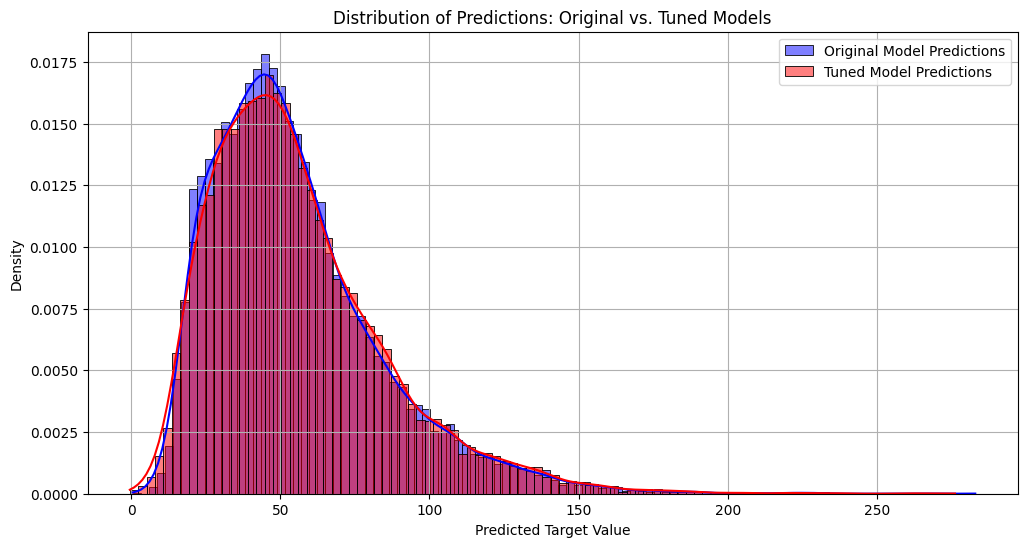

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(submission_original['target'], color='blue', label='Original Model Predictions', kde=True, stat='density', alpha=0.5)
sns.histplot(submission_tuned['target'], color='red', label='Tuned Model Predictions', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Predictions: Original vs. Tuned Models')
plt.xlabel('Predicted Target Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print('Descriptive statistics for Original Model Predictions:')
display(submission_original['target'].describe())

print('\nDescriptive statistics for Tuned Model Predictions:')
display(submission_tuned['target'].describe())


Descriptive statistics for Original Model Predictions:


,target
count,16136.000000
mean,55.195807
std,28.753542
min,0.510567
25%,34.706720
50%,49.583720
75%,68.836628
max,282.994420



Descriptive statistics for Tuned Model Predictions:


,target
count,16136.000000
mean,55.802132
std,29.721695
min,-0.456414
25%,34.588338
50%,50.191853
75%,70.494240
max,276.204285


In [ ]:
import pandas as pd

# Load the original submission file
submission_original = pd.read_csv('my_submission.csv')

# Load the tuned submission file
submission_tuned = pd.read_csv('my_submission_tuned.csv')

print("Original Submission (first 5 rows):")
display(submission_original.head())

print("\nTuned Submission (first 5 rows):")
display(submission_tuned.head())

# Calculate the difference in predictions
# Ensure both dataframes are aligned on 'Place_ID X Date' for accurate comparison
# Assuming 'Place_ID X Date' is unique and can be used as an index

# Set 'Place_ID X Date' as index for alignment
submission_original = submission_original.set_index('Place_ID X Date')
submission_tuned = submission_tuned.set_index('Place_ID X Date')

# Calculate the absolute difference in target predictions
difference = (submission_original['target'] - submission_tuned['target']).abs()

print(f"\nMean Absolute Difference between original and tuned predictions: {difference.mean():.4f}")
print(f"Maximum Absolute Difference between original and tuned predictions: {difference.max():.4f}")

# Reset index if further operations require it
submission_original = submission_original.reset_index()
submission_tuned = submission_tuned.reset_index()


Original Submission (first 5 rows):


,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,39.796494
1,0OS9LVX X 2020-01-03,34.200874
2,0OS9LVX X 2020-01-04,36.372720
3,0OS9LVX X 2020-01-05,36.382576
4,0OS9LVX X 2020-01-06,33.109993



Tuned Submission (first 5 rows):


,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,43.121475
1,0OS9LVX X 2020-01-03,31.184046
2,0OS9LVX X 2020-01-04,36.160137
3,0OS9LVX X 2020-01-05,36.401188
4,0OS9LVX X 2020-01-06,32.250156



Mean Absolute Difference between original and tuned predictions: 6.2111
Maximum Absolute Difference between original and tuned predictions: 44.7371


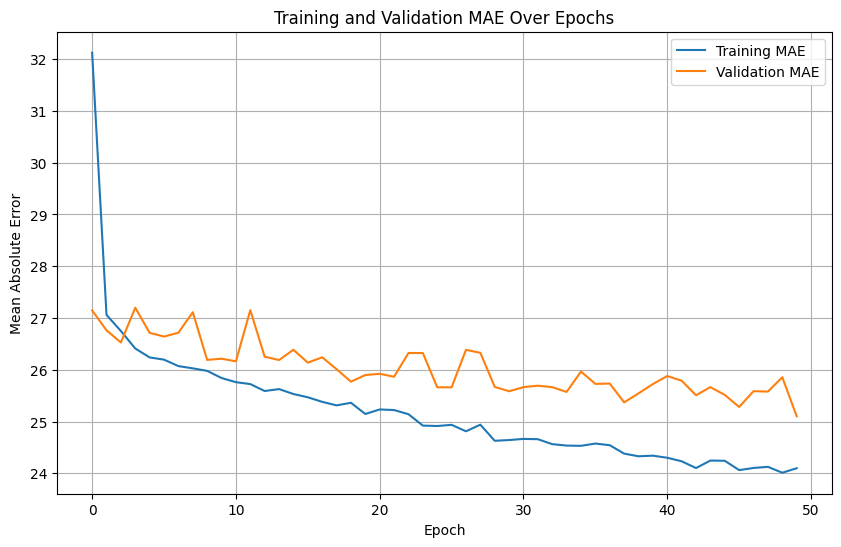

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

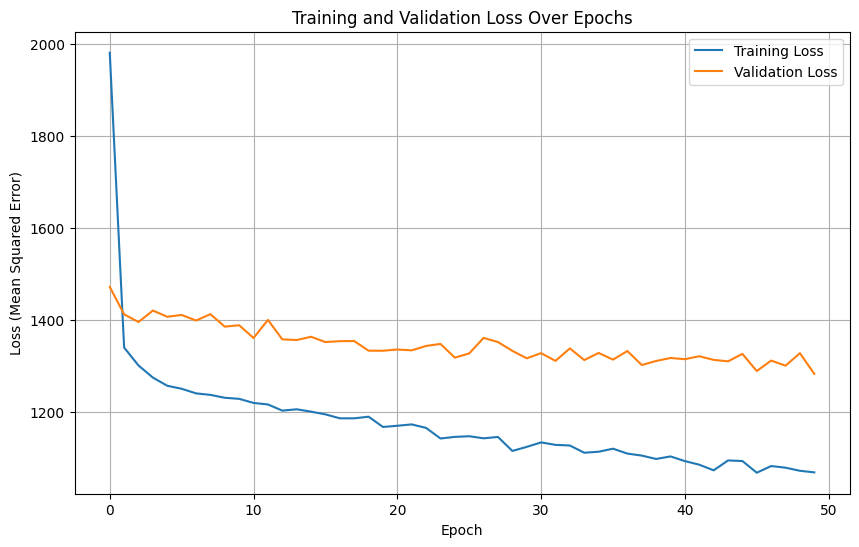

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

Final Training Loss (MSE): 1067.6322
Final Validation Loss (MSE): 1282.0289
Final Training MAE: 24.0977
Final Validation MAE: 25.1020


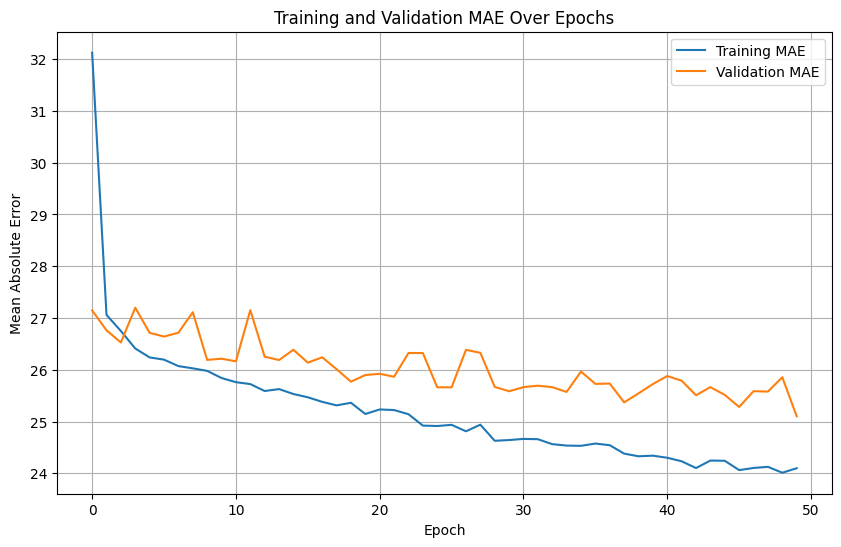

In [ ]:
print(f"Final Training Loss (MSE): {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss (MSE): {history.history['val_loss'][-1]:.4f}")
print(f"Final Training MAE: {history.history['mae'][-1]:.4f}")
print(f"Final Validation MAE: {history.history['val_mae'][-1]:.4f}")

# Plot training and validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

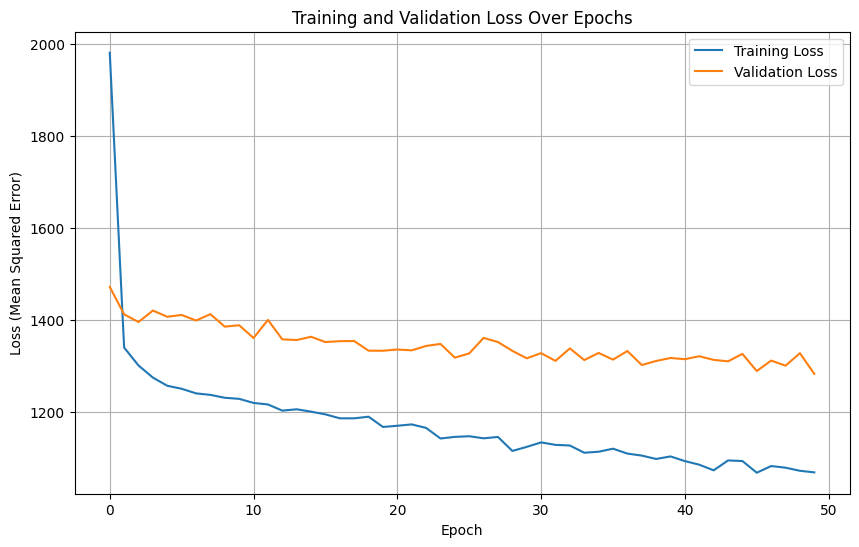

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()